# PTB-XL — download, convert, label, visualize

[PTB-XL](https://physionet.org/content/ptb-xl/1.0.3/) (~21 799 × 10 s, 12-lead). About **3 GB** uncompressed if you take every 500 Hz record — always subset.

Thesis role: **~9.5k NORM** vs MI / ST-T / conduction / hypertrophy, ~50/50 sex, recommended folds 9 (val) and 10 (test). Primary use: **false-alarm rate** of Graph_Visualizer rules on labelled-normal ECGs, plus sensitivity on MI/STTC.

Labels follow SCP-ECG: per-statement likelihoods, diagnostic superclass/subclass, form, rhythm, demographics, `strat_fold`.

In [1]:
from pathlib import Path
import sys

REPO = Path.cwd() if (Path.cwd() / "evaluation" / "common.py").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO / "evaluation"))

import numpy as np
import pandas as pd
import wfdb
from IPython.display import display

import common as C

# --- subset ---
N_RECORDS = 24
SAMPLING = 500                 # 500 (records500/*_hr) recommended; 100 is smaller
STRAT_FOLDS = [10]             # paper: 1–8 train, 9 val, 10 test; None = any
SUPERCLASSES = None            # e.g. ["NORM", "MI", "STTC"]; None = any
SEX = None                     # 0=male, 1=female, None=both
BALANCED_NORM_ABNORMAL = True  # half NORM, half not — false-alarm vs detection
OVERWRITE_PROCESSED = False
SEED = 42

RAW_DIR, PROC_DIR = C.dataset_dirs("ptb_xl")
FALLBACK = [REPO / "data" / "ptb-xl"]
print("raw:", RAW_DIR)
print("processed:", PROC_DIR)

raw: C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\raw\ptb_xl
processed: C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\processed\ptb_xl


## 1. Metadata only (small) — then choose a subset

In [2]:
meta_files = ["ptbxl_database.csv", "scp_statements.csv"]
print(C.summarize_status(
    C.download_files("ptb-xl", meta_files, RAW_DIR, version="1.0.3")
))

meta = pd.read_csv(RAW_DIR / "ptbxl_database.csv")
statements = pd.read_csv(RAW_DIR / "scp_statements.csv", index_col=0)
print(f"PTB-XL rows: {len(meta)}  statements: {len(statements)}")

selected = C.select_ptbxl_subset(
    meta,
    statements,
    n_records=N_RECORDS,
    superclasses=SUPERCLASSES,
    strat_folds=STRAT_FOLDS,
    sex=SEX,
    balanced_norm_abnormal=BALANCED_NORM_ABNORMAL,
    seed=SEED,
)
print(
    selected.assign(
        supers=selected["diagnostic_superclasses"].map(lambda x: ",".join(x))
    )[["ecg_id", "patient_id", "sex", "age", "strat_fold", "is_norm", "supers", "filename_hr"]].head(12)
)
print("NORM / abnormal:", int(selected["is_norm"].sum()), "/", int((~selected["is_norm"]).sum()))

Finished downloading files
downloaded=2
PTB-XL rows: 21799  statements: 71
      ecg_id  patient_id  sex   age  strat_fold  is_norm supers  \
392      400     10987.0    1  38.0          10    False   STTC   
1001    1014      2901.0    0  78.0          10    False  CD,MI   
1302    1315     13702.0    1  25.0          10     True   NORM   
1704    1717     20306.0    0  71.0          10    False          
2026    2039       307.0    1  59.0          10    False   STTC   
3553    3568      9001.0    0  77.0          10    False  CD,MI   
4234    4254     20030.0    0  70.0          10    False     CD   
5717    5737      6208.0    0  41.0          10     True   NORM   
6477    6498       933.0    0  54.0          10     True   NORM   
7059    7080     11293.0    1  74.0          10     True   NORM   
8986    9010      8001.0    0  61.0          10     True   NORM   
9849    9875     20737.0    0  71.0          10    False  CD,MI   

                    filename_hr  
392   records500/00

## 2. Download only the chosen waveforms

In [3]:
col = "filename_hr" if SAMPLING == 500 else "filename_lr"
files = []
for rel in selected[col].tolist():
    files.extend([f"{rel}.dat", f"{rel}.hea"])

status = C.download_files("ptb-xl", files, RAW_DIR, fallback_dirs=FALLBACK, version="1.0.3")
print("waveforms:", C.summarize_status(status))
failed = [k for k, v in status.items() if v == "failed"]
if failed:
    print("failed:", failed[:10])

Finished downloading files
waveforms: downloaded=48


## 3. Convert to `.npy` + SCP labels

In [4]:
index_rows = []
col = "filename_hr" if SAMPLING == 500 else "filename_lr"

for _, row in selected.iterrows():
    rec_id = f"{int(row['ecg_id']):05d}_{'hr' if SAMPLING == 500 else 'lr'}"
    if C.processed_exists(PROC_DIR, rec_id) and not OVERWRITE_PROCESSED:
        print(f"skip processed {rec_id}")
        continue

    rel = str(row[col]).replace("\\", "/")
    rec_path = RAW_DIR / rel
    if not rec_path.with_suffix(".hea").is_file():
        rec_path = FALLBACK[0] / Path(rel).name.replace(".dat", "")
        # local sample lives as data/ptb-xl/00001_hr
        rec_path = FALLBACK[0] / rec_id if (FALLBACK[0] / f"{rec_id}.hea").is_file() else rec_path
    if not rec_path.with_suffix(".hea").is_file():
        print(f"missing {rel}, skip")
        continue

    record = wfdb.rdrecord(str(rec_path))
    signal_12, channels = C.to_12_lead(record.p_signal.T, record.sig_name)
    C.save_signal_pair(PROC_DIR / "signals" / rec_id, signal_12, record.fs, channels)

    scp = C.parse_scp_codes(row["scp_codes"])
    dx = C.ptbxl_diagnostic_labels(scp, statements)
    payload = {
        "dataset": "ptb_xl",
        "record_id": rec_id,
        "ecg_id": int(row["ecg_id"]),
        "patient_id": int(row["patient_id"]),
        "fs": int(record.fs),
        "n_samples": int(record.sig_len),
        "channels": channels,
        "age": None if pd.isna(row.get("age")) else float(row["age"]),
        "sex": int(row["sex"]) if pd.notna(row.get("sex")) else None,
        "sex_label": {0: "male", 1: "female"}.get(int(row["sex"]) if pd.notna(row.get("sex")) else -1),
        "strat_fold": int(row["strat_fold"]) if pd.notna(row.get("strat_fold")) else None,
        "report": None if pd.isna(row.get("report")) else str(row["report"]),
        "heart_axis": None if pd.isna(row.get("heart_axis")) else str(row["heart_axis"]),
        "infarction_stadium1": None if pd.isna(row.get("infarction_stadium1")) else str(row["infarction_stadium1"]),
        "validated_by_human": None if pd.isna(row.get("validated_by_human")) else bool(row["validated_by_human"]),
        **dx,
    }
    C.save_label_json(PROC_DIR / "labels" / f"{rec_id}.json", payload)
    index_rows.append({
        "record_id": rec_id,
        "ecg_id": int(row["ecg_id"]),
        "patient_id": int(row["patient_id"]),
        "sex": payload["sex_label"],
        "age": payload["age"],
        "strat_fold": payload["strat_fold"],
        "is_norm": dx["is_norm"],
        "superclasses": ";".join(dx["diagnostic_superclasses"]),
        "subclasses": ";".join(dx["diagnostic_subclasses"]),
        "scp_codes": ";".join(f"{k}:{v}" for k, v in scp.items()),
        "npy": str((PROC_DIR / "signals" / f"{rec_id}.npy").relative_to(C.REPO_ROOT)),
    })
    print(f"wrote {rec_id}  NORM={dx['is_norm']}  {dx['diagnostic_superclasses']}")

C.write_index(PROC_DIR, index_rows)
index = pd.read_csv(PROC_DIR / "index.csv")
display(index.head())
print(f"index rows: {len(index)}")

wrote 00400_hr  NORM=False  ['STTC']
wrote 01014_hr  NORM=False  ['CD', 'MI']
wrote 01315_hr  NORM=True  ['NORM']
wrote 01717_hr  NORM=False  []
wrote 02039_hr  NORM=False  ['STTC']
wrote 03568_hr  NORM=False  ['CD', 'MI']
wrote 04254_hr  NORM=False  ['CD']
wrote 05737_hr  NORM=True  ['NORM']
wrote 06498_hr  NORM=True  ['NORM']
wrote 07080_hr  NORM=True  ['NORM']
wrote 09010_hr  NORM=True  ['NORM']
wrote 09875_hr  NORM=False  ['CD', 'MI']
wrote 12677_hr  NORM=True  ['NORM']
wrote 12925_hr  NORM=True  ['NORM']
wrote 14637_hr  NORM=True  ['NORM']
wrote 14976_hr  NORM=True  ['NORM']
wrote 15101_hr  NORM=False  ['CD']
wrote 15631_hr  NORM=False  ['STTC']
wrote 16144_hr  NORM=True  ['NORM']
wrote 16147_hr  NORM=True  ['NORM']
wrote 16566_hr  NORM=False  ['MI']
wrote 17827_hr  NORM=True  ['NORM']
wrote 18712_hr  NORM=False  ['HYP', 'MI', 'STTC']
wrote 19388_hr  NORM=False  ['MI', 'STTC']


,record_id,ecg_id,patient_id,sex,age,strat_fold,is_norm,superclasses,subclasses,scp_codes,npy
0,00400_hr,400,10987,female,38.0,10,False,STTC,STTC,NDT:100.0;SR:0.0,data\evaluation\processed\ptb_xl\signals\00400...
1,01014_hr,1014,2901,male,78.0,10,False,CD;MI,AMI;_AVB,AMI:100.0;1AVB:100.0;NT_:0.0;LPR:0.0;SR:0.0,data\evaluation\processed\ptb_xl\signals\01014...
2,01315_hr,1315,13702,female,25.0,10,True,NORM,NORM,NORM:100.0;SR:0.0,data\evaluation\processed\ptb_xl\signals\01315...
3,01717_hr,1717,20306,male,71.0,10,False,NaN,NaN,PACE:100.0;SBRAD:0.0,data\evaluation\processed\ptb_xl\signals\01717...
4,02039_hr,2039,307,female,59.0,10,False,STTC,STTC,NDT:100.0;LOWT:0.0;STACH:0.0,data\evaluation\processed\ptb_xl\signals\02039...


index rows: 24


## 4. Visualizations

PTB-XL is a **population / statement** dataset: NORM vs pathology, sex balance, SCP superclasses, and a side-by-side 12-lead of one normal and one abnormal record.

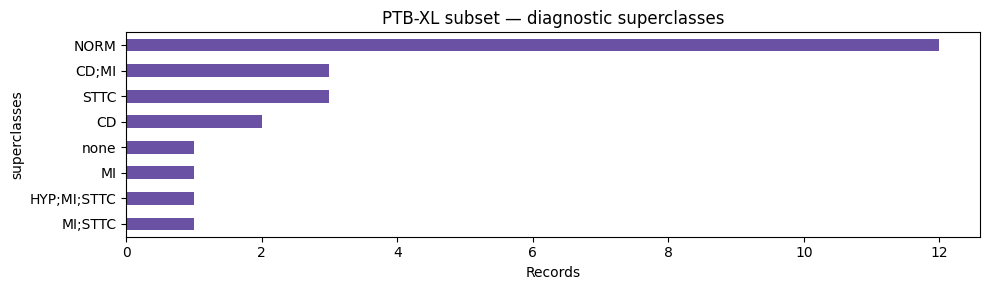

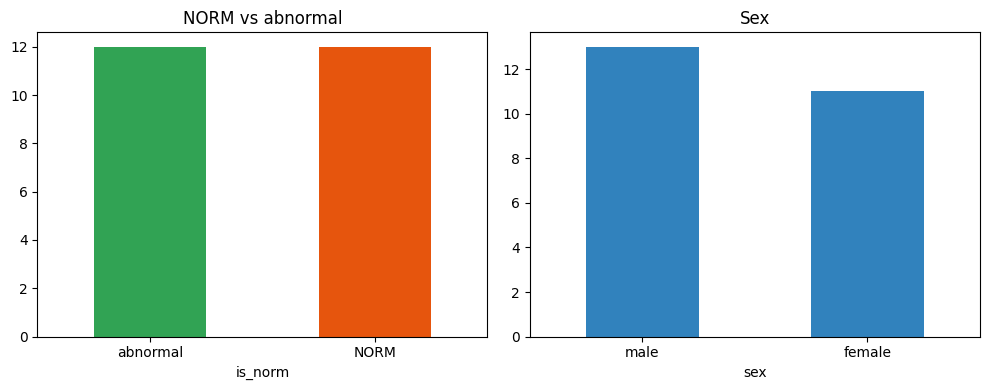

In [5]:
import json
import pickle
from matplotlib import pyplot as plt

index = pd.read_csv(PROC_DIR / "index.csv")

fig, ax = C.plot_category_counts(
    index["superclasses"].fillna("none").value_counts(),
    title="PTB-XL subset — diagnostic superclasses",
    color="#6a51a3",
)
C.save_figure(fig, PROC_DIR, "ptbxl_superclasses")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
index["is_norm"].map({True: "NORM", False: "abnormal"}).value_counts().plot.bar(
    ax=axes[0], color=["#31a354", "#e6550d"]
)
axes[0].set_title("NORM vs abnormal")
axes[0].tick_params(axis="x", rotation=0)
index["sex"].fillna("unknown").value_counts().plot.bar(ax=axes[1], color="#3182bd")
axes[1].set_title("Sex")
axes[1].tick_params(axis="x", rotation=0)
fig.tight_layout()
C.save_figure(fig, PROC_DIR, "ptbxl_norm_sex")
display(fig)
plt.close(fig)

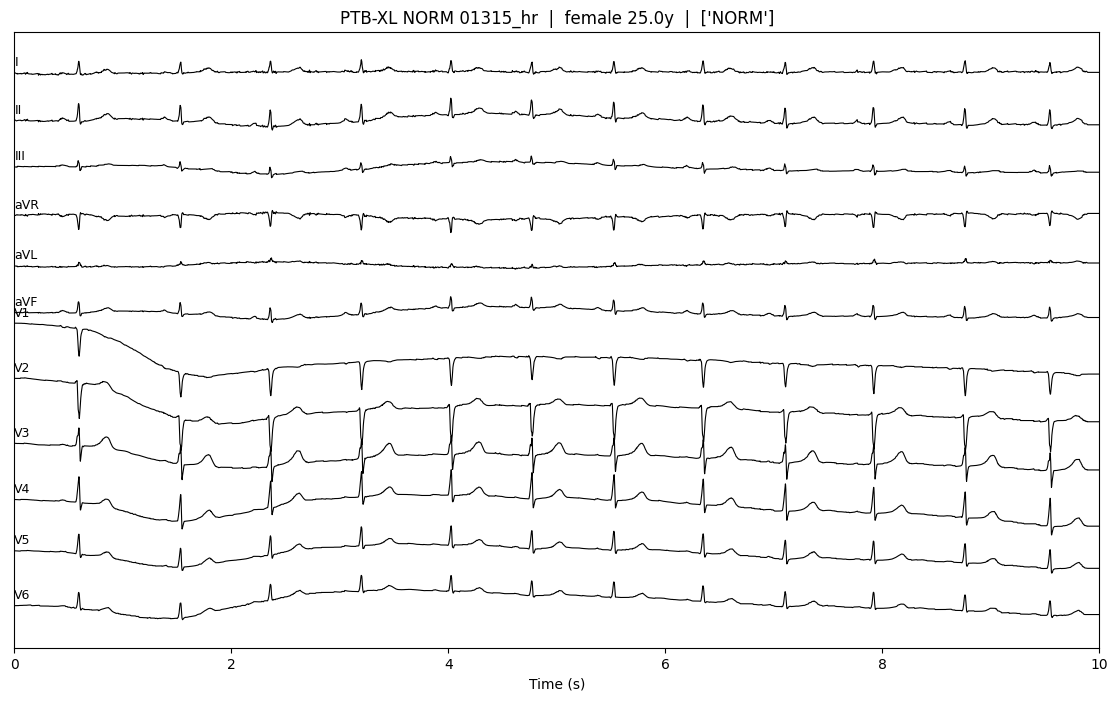

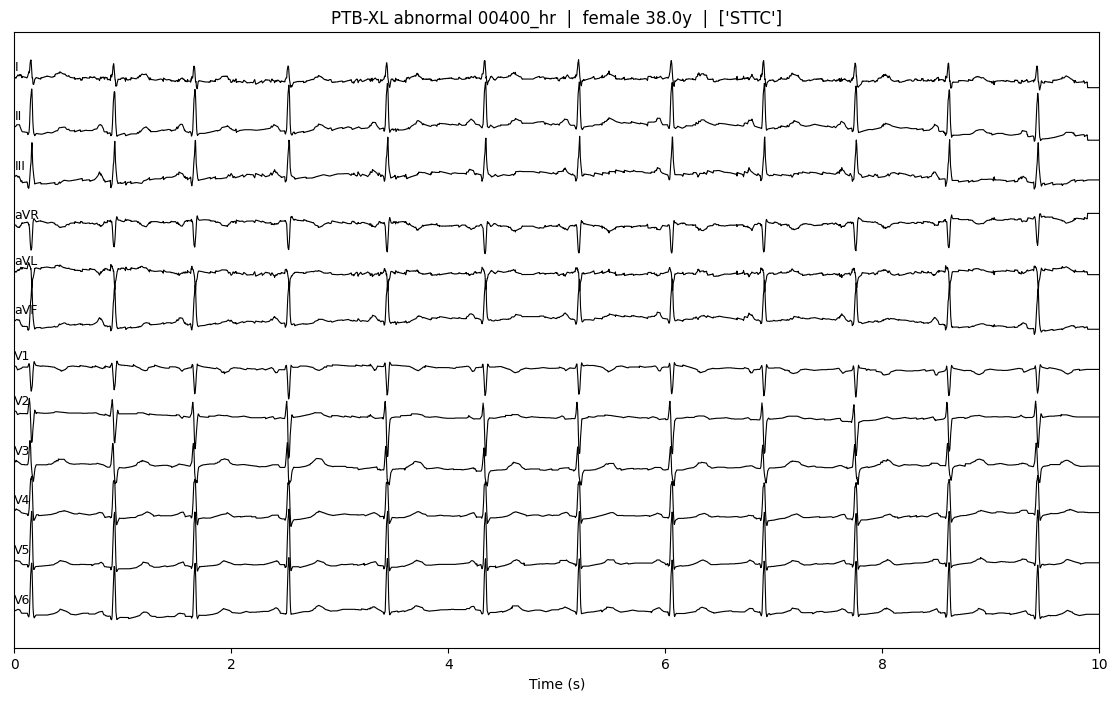

Figures → C:\Users\staso\OneDrive\Pulpit\Nauka\University\Thesis\code\ECG_Delineation\WTdelineator\data\evaluation\processed\ptb_xl\figures


In [6]:
def show_record(rec_id: str, title: str, fname: str):
    sig = np.load(PROC_DIR / "signals" / f"{rec_id}.npy")
    with open(PROC_DIR / "signals" / f"{rec_id}.pkl", "rb") as f:
        meta = pickle.load(f)
    labels = json.loads((PROC_DIR / "labels" / f"{rec_id}.json").read_text(encoding="utf-8"))
    fig, ax = C.plot_12_lead_strip(
        sig, meta["fs"], meta["channels"],
        title=f"{title}  |  {labels.get('sex_label')} {labels.get('age')}y  |  {labels.get('diagnostic_superclasses')}",
    )
    C.save_figure(fig, PROC_DIR, fname)
    display(fig)
    plt.close(fig)

norm_ids = index.loc[index["is_norm"].astype(bool), "record_id"]
abn_ids = index.loc[~index["is_norm"].astype(bool), "record_id"]
if len(norm_ids):
    show_record(str(norm_ids.iloc[0]), f"PTB-XL NORM {norm_ids.iloc[0]}", "ptbxl_example_norm")
if len(abn_ids):
    show_record(str(abn_ids.iloc[0]), f"PTB-XL abnormal {abn_ids.iloc[0]}", "ptbxl_example_abnormal")

print("Figures →", PROC_DIR / "figures")